In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [2]:
# 1. Load dataset
data = pd.read_csv("spam.csv", encoding='latin-1')

data = data[['label','message']]
data.columns = ['label','message']

print(data.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
# 2. Convert label (spam=1, ham=0)
data['label'] = data['label'].map({'ham':0, 'spam':1})

In [4]:
# 3. Train test split
X_train, X_test, y_train, y_test = train_test_split(
    data['message'],
    data['label'],
    test_size=0.2,
    random_state=42
)

In [5]:
# 4. Convert text → vector
vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [6]:
# 5. Naive Bayes

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, nb_pred))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

Naive Bayes Accuracy:
0.97847533632287

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:
[[966   0]
 [ 24 125]]


In [7]:
# 6. Logistic Regression

lr_model = LogisticRegression()
lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)

print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))



Logistic Regression Accuracy:
0.9695067264573991

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:
[[966   0]
 [ 34 115]]


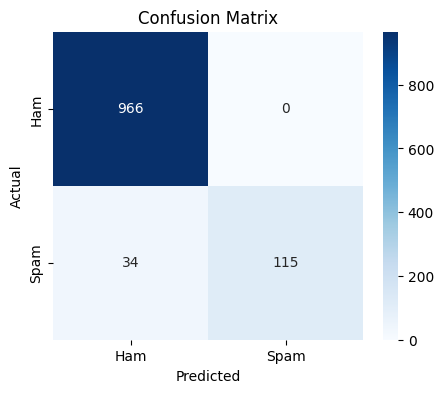

In [8]:
# 7. Confusion Matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

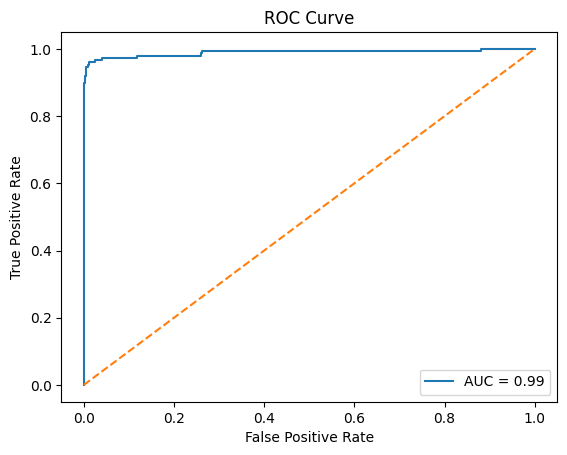

In [9]:
# 8. ROC Curve

prob = lr_model.predict_proba(X_test_vec)[:,1]

fpr, tpr, threshold = roc_curve(y_test, prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [10]:
# 9. Test with new message

def predict_message(msg):

    msg_vec = vectorizer.transform([msg])

    pred = lr_model.predict(msg_vec)[0]

    if pred == 1:
        print("Spam")
    else:
        print("Not Spam")

In [11]:
predict_message("Congratulations! you won a free ticket")
predict_message("Hey, are we meeting today?")
predict_message("WINNER!! You have won $1000 cash prize")
predict_message("URGENT! Claim your free reward now")
predict_message("Free entry in a weekly competition")
predict_message("")

Not Spam
Not Spam
Spam
Spam
Not Spam
Not Spam
